<a href="https://colab.research.google.com/github/bismillah626/spam_project/blob/main/spam_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

# ***#1 Data cleaning***

In [2]:
df = pd.read_csv('/content/spam.csv',encoding='latin-1').dropna(axis =1,how = 'any')
df.columns = ['labels','message']
df

,labels,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [3]:
df.isnull().sum()

,0
labels,0
message,0


In [4]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['labels'] = le.fit_transform(df['labels'])

In [5]:
df.sample(5)

,labels,message
3933,0,How come guoyang go n tell her? Then u told her?
1571,0,Near kalainar tv office.thenampet
1159,0,Yun buying... But school got offer 2000 plus o...
4045,1,Win a å£1000 cash prize or a prize worth å£5000
5152,0,Idk. I'm sitting here in a stop and shop parki...


In [6]:
#checking for duplicate values
df.duplicated().sum()

np.int64(403)

In [7]:
df  = df.drop_duplicates(keep = 'first')

In [8]:
df.shape

(5169, 2)

# ***#2 EDA***

In [9]:
#checks if the data is balanced or not
df['labels'].value_counts()

,count
labels,
0,4516
1,653


Text(0, 0.5, 'count')

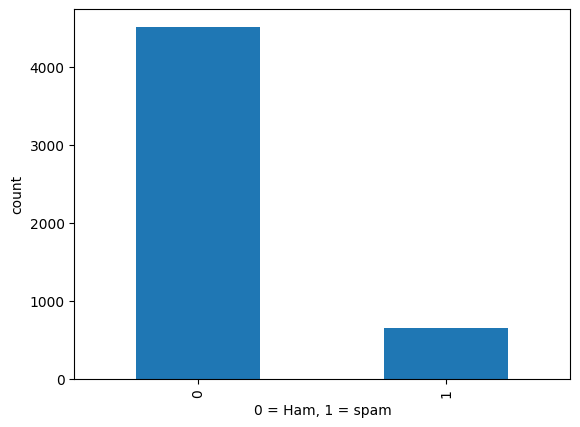

In [10]:
#schematic representation of data in piechart and bargraph format
import matplotlib.pyplot as plt
df['labels'].value_counts().plot(kind = 'bar')
plt.xlabel('0 = Ham, 1 = spam')
plt.ylabel('count')


([<matplotlib.patches.Wedge at 0x7840fa4b7920>,
 [Text(-1.014499732282844, 0.4251944181172162, 'ham'),
  Text(1.0144998708287172, -0.42519408755122207, 'spam')],
 [Text(-0.5533634903360967, 0.2319242280639361, '87.37'),
  Text(0.553363565906573, -0.231924047755212, '12.63')])

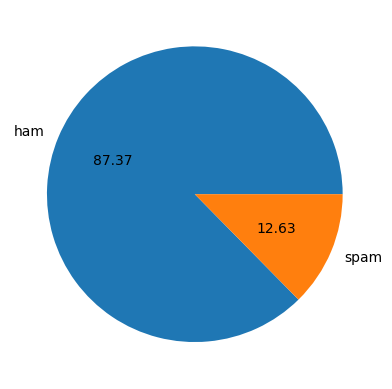

In [11]:
#piechart
plt.pie(df['labels'].value_counts(),labels = ['ham','spam'],autopct = '%0.2f')


In [12]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [13]:
df['characters_count'] = df['message'].apply(len)

/tmp/ipython-input-1212001223.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['characters_count'] = df['message'].apply(len)


In [14]:
df.sample(5)

,labels,message,characters_count
1168,0,Ok . . now i am in bus. . If i come soon i wil...,71
122,1,Todays Voda numbers ending 7548 are selected t...,156
5134,0,Sday only joined.so training we started today:),47
3004,0,Ew are you one of them?,23
1181,0,You flippin your shit yet?,26


In [15]:
df['words_count'] = df['message'].apply(lambda x: len(nltk.tokenize.word_tokenize(x)))

/tmp/ipython-input-267352958.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['words_count'] = df['message'].apply(lambda x: len(nltk.tokenize.word_tokenize(x)))


In [16]:
df['sentence count'] = df['message'].apply(lambda x: len(nltk.sent_tokenize(x)))

/tmp/ipython-input-1666743428.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sentence count'] = df['message'].apply(lambda x: len(nltk.sent_tokenize(x)))


In [17]:
df.head()

,labels,message,characters_count,words_count,sentence count
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [18]:
df.sample(5)

,labels,message,characters_count,words_count,sentence count
59,0,Yes..gauti and sehwag out of odi series.,40,10,1
415,0,Whatsup there. Dont u want to sleep,35,8,2
3718,1,"Thanks for your ringtone order, reference numb...",197,38,4
3189,0,Hi neva worry bout da truth coz the truth will...,137,30,3
1090,1,WIN URGENT! Your mobile number has been awarde...,147,26,3


In [19]:
df[['sentence count','words_count','characters_count']].describe()

,sentence count,words_count,characters_count
count,5169.000000,5169.000000,5169.000000
mean,1.965564,18.455794,78.977945
std,1.448541,13.324758,58.236293
min,1.000000,1.000000,2.000000
25%,1.000000,9.000000,36.000000
50%,1.000000,15.000000,60.000000
75%,2.000000,26.000000,117.000000
max,38.000000,220.000000,910.000000


In [20]:
#spam message analysis
df[df['labels']==1][['sentence count', 'words_count', 'characters_count']].describe()

,sentence count,words_count,characters_count
count,653.000000,653.000000,653.000000
mean,2.970904,27.667688,137.891271
std,1.488425,7.008418,30.137753
min,1.000000,2.000000,13.000000
25%,2.000000,25.000000,132.000000
50%,3.000000,29.000000,149.000000
75%,4.000000,32.000000,157.000000
max,9.000000,46.000000,224.000000


In [21]:
#ham  message analysis
df[df['labels']==0][['sentence count', 'words_count', 'characters_count']].describe()


,sentence count,words_count,characters_count
count,4516.000000,4516.000000,4516.000000
mean,1.820195,17.123782,70.459256
std,1.383657,13.493970,56.358207
min,1.000000,1.000000,2.000000
25%,1.000000,8.000000,34.000000
50%,1.000000,13.000000,52.000000
75%,2.000000,22.000000,90.000000
max,38.000000,220.000000,910.000000


<Axes: xlabel='characters_count', ylabel='Count'>

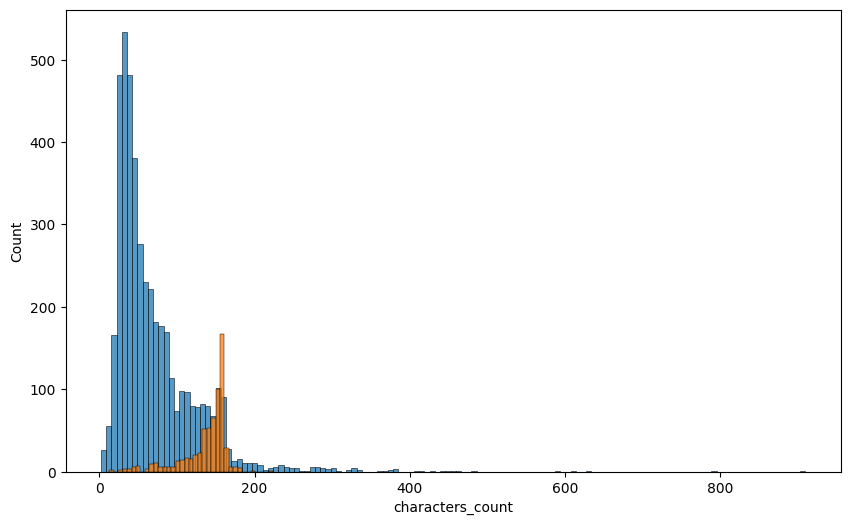

In [22]:
#Comparing the number of characters and numbere of words in spam and ham messages
import seaborn as sns
plt.figure(figsize = (10,6))
sns.histplot(df[df['labels']== 0]['characters_count'])
sns.histplot(df[df['labels']== 1]['characters_count'])

<Axes: xlabel='words_count', ylabel='Count'>

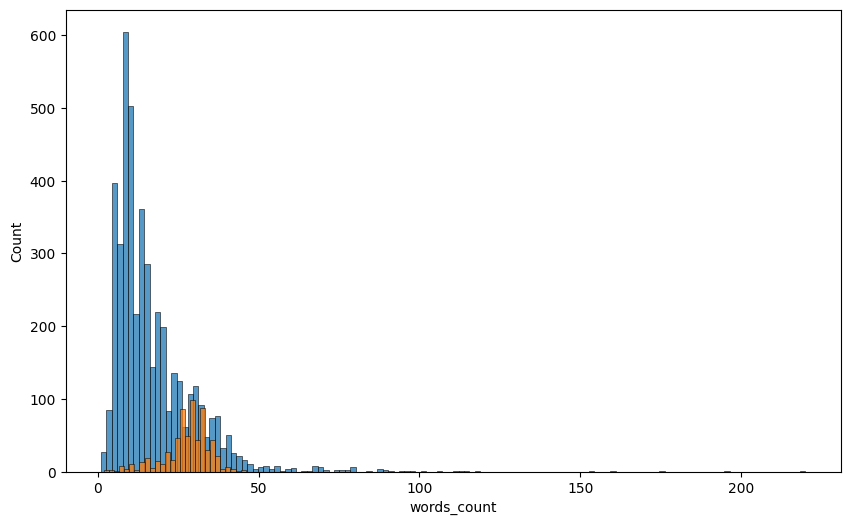

In [23]:
plt.figure(figsize = (10,6))
sns.histplot(df[df['labels']==0]['words_count'])
sns.histplot(df[df['labels']==1]['words_count'])

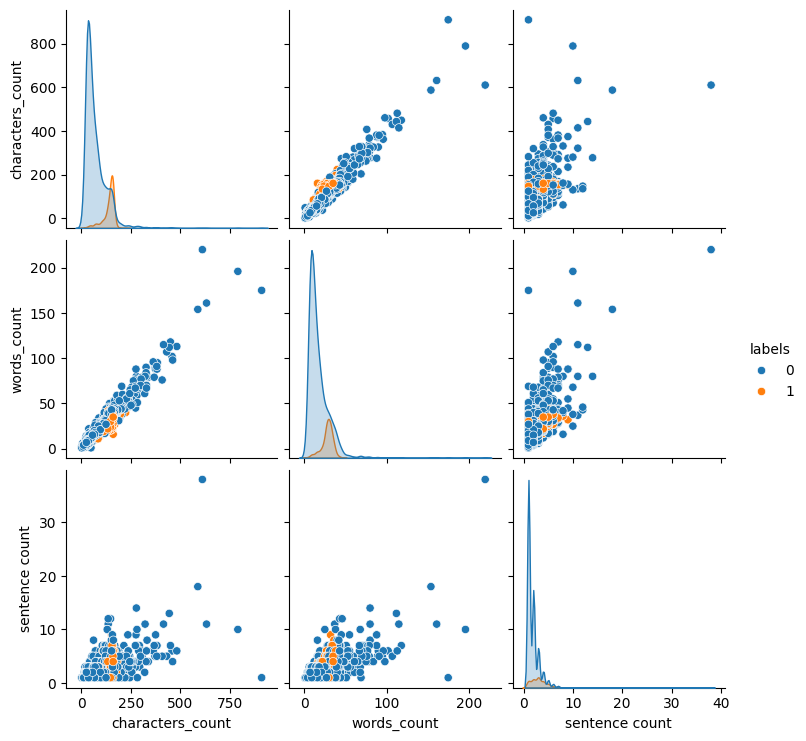

In [24]:
sns.pairplot(df,hue = 'labels')

In [25]:
from wordcloud import WordCloud
wc = WordCloud(width = 500 , height = 500 , min_font_size = 10 , background_color = 'white')

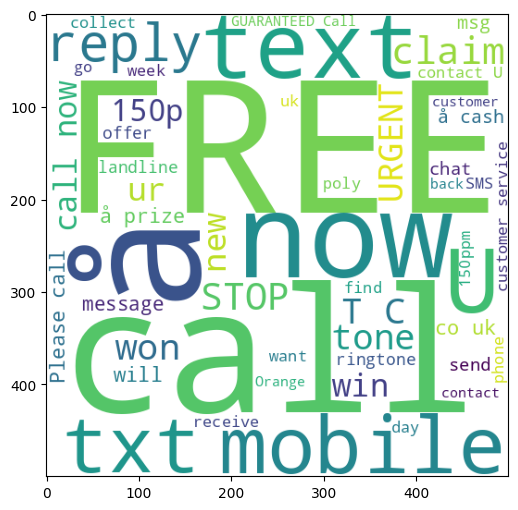

In [31]:
#for spam
spam_wc = wc.generate(df[df['labels'] == 1]['message'].str.cat(sep = " "))
plt.figure(figsize = (15,6))
plt.imshow(spam_wc)

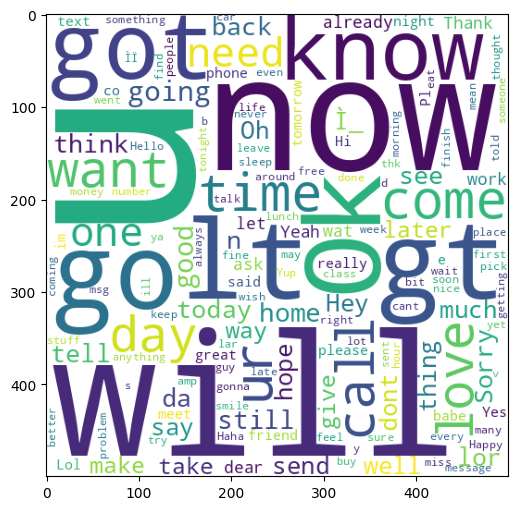

In [33]:
#ham message info
ham_wc = wc.generate(df[df['labels']==0]['message'].str.cat(sep = " "))
plt.figure(figsize = (15,6))
plt.imshow(ham_wc)

In [35]:
spam_corpus = []
for msg in df[df['labels']==1]['message'].tolist():

  for word in msg.split():
    spam_corpus.append(word)

In [37]:
len(spam_corpus)

15464

/tmp/ipython-input-3353852527.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = pd.DataFrame(Counter(spam_corpus).most_common(30))[0],y = pd.DataFrame(Counter(spam_corpus).most_common(30))[1],palette = sns.color_palette("husl",8))
/tmp/ipython-input-3353852527.py:2: UserWarning: 
The palette list has fewer values (8) than needed (30) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x = pd.DataFrame(Counter(spam_corpus).most_common(30))[0],y = pd.DataFrame(Counter(spam_corpus).most_common(30))[1],palette = sns.color_palette("husl",8))


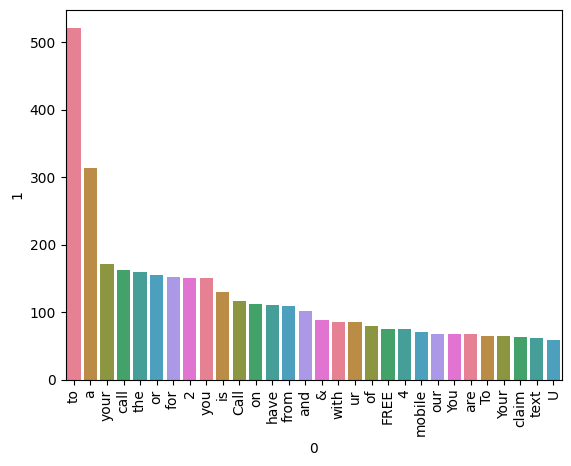

In [50]:
from collections import Counter
sns.barplot(x = pd.DataFrame(Counter(spam_corpus).most_common(30))[0],y = pd.DataFrame(Counter(spam_corpus).most_common(30))[1],palette = sns.color_palette("husl",8))
plt.xticks(rotation = 'vertical')
plt.show(       )

In [51]:
ham_corpus = []
for msg in df[df['labels']== 0]['message']:
  for word in msg.split():
    ham_corpus.append(word)


In [52]:
len(ham_corpus)

63832

/tmp/ipython-input-463792093.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = pd.DataFrame(Counter(ham_corpus).most_common(30))[0],y = pd.DataFrame(Counter(ham_corpus).most_common(30))[1],palette = sns.color_palette("viridis"))
/tmp/ipython-input-463792093.py:1: UserWarning: 
The palette list has fewer values (6) than needed (30) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x = pd.DataFrame(Counter(ham_corpus).most_common(30))[0],y = pd.DataFrame(Counter(ham_corpus).most_common(30))[1],palette = sns.color_palette("viridis"))


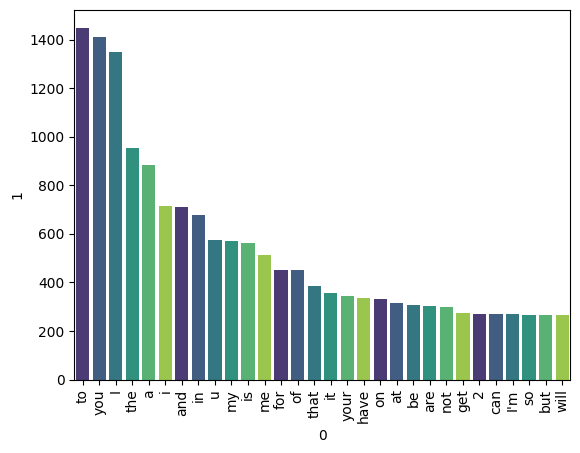

In [53]:
sns.barplot(x = pd.DataFrame(Counter(ham_corpus).most_common(30))[0],y = pd.DataFrame(Counter(ham_corpus).most_common(30))[1],palette = sns.color_palette("viridis"))
plt.xticks(rotation='vertical')
plt.show()